# AE for dimensionality reduction on Salinity, Temperature and Oxygen (STO) scaled data - GMM clustering

In [7]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

In [8]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_ST = df_ST.dropna()

In [9]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [10]:
# Standardize the features
scaler = StandardScaler()
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]']
df_ST_scaled = scaler.fit_transform(df_ST[features])

In [11]:
# set seed for reproducibility
tf.random.set_seed(seed)

# Autoencoder architecture
input_dim = df_ST_scaled.shape[1]
latent_dim = 2

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
latent = layers.Dense(latent_dim, name="latent")(x)

# Decoder
x = layers.Dense(8, activation='relu')(latent)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

autoencoder = models.Model(inputs, outputs)
encoder = models.Model(inputs, latent)

In [12]:
early_stopping = EarlyStopping(
    monitor='val_loss',   # validation loss checked for early stopping
    patience=5,           # how many epochs to wait before stopping
    restore_best_weights=True
)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.fit(
    df_ST_scaled,
    df_ST_scaled,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step - loss: 0.0224 - val_loss: 0.0071
Epoch 2/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0094 - val_loss: 0.0056
Epoch 3/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0073 - val_loss: 0.0048
Epoch 4/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0058 - val_loss: 0.0044
Epoch 5/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0055 - val_loss: 0.0042
Epoch 6/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0053 - val_loss: 0.0039
Epoch 7/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 8/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0048 - val_loss: 0.0037
Epoch 9/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 10/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0044 - val_loss: 0.0040
Epoch 11/50
16461/16461 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step - loss: 0.0043 - val_loss: 0.00

36580/36580 ━━━━━━━━━━━━━━━━━━━━ 20s 553us/step


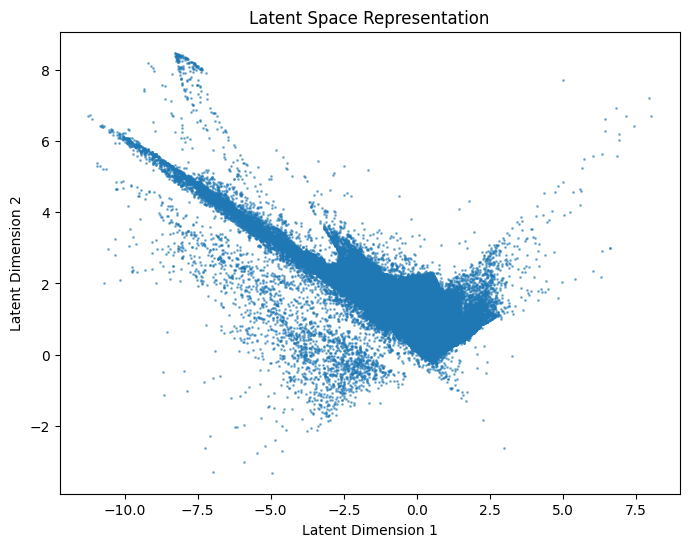

In [13]:
X_latent = encoder.predict(df_ST_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_latent[:,0], X_latent[:,1], s=1, alpha=0.5)
plt.title('Latent Space Representation')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.show()

In [14]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
    gmm.fit(X_latent)
    bic_scores.append(gmm.bic(X_latent))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

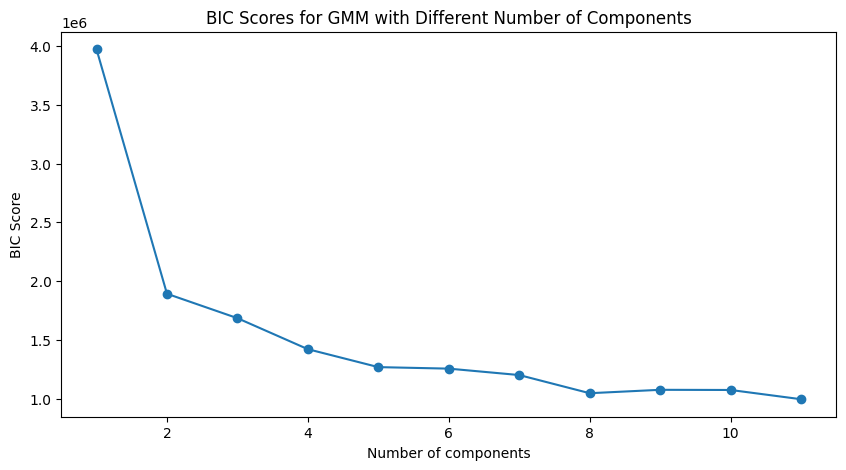

In [15]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [16]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 8

In [17]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(X_latent)

In [18]:
df_ST['gmm_label'] = labels

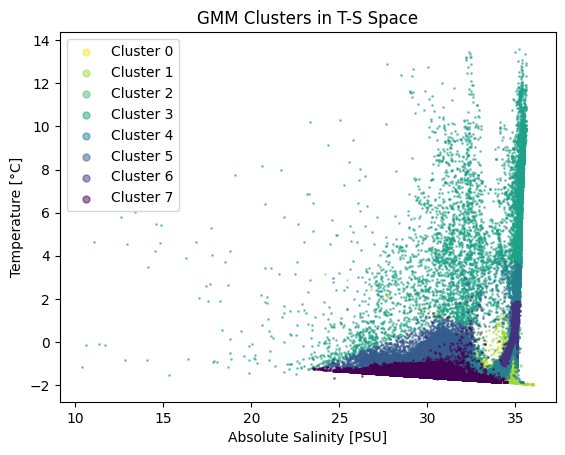

In [19]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_ST['gmm_label'] == i
    plt.scatter(
        df_ST.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_ST.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [20]:
# Sample geographically for better plotting
df_sampled = df_ST.sample(n=100000, random_state=seed)

In [21]:
# Compute data centroid (mean location)
center_lat = df_ST['Latitude_[deg_N]'].mean()
center_lon = df_ST['Longitude_[deg_E]'].mean()

colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma, # Colour scale same as continuous colour bar version but sampled to be discrete
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="GMM clusters using TSO on geographic map"
)

fig.update_traces(
    marker=dict(size=5, opacity=0.9)
)

fig.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig.add_trace(
        go.Scattergeo(
            lat=[None], lon=[None],   # invisible
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig.update_layout(
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig.show()

In [22]:
# Plot in 3D
colors = px.colors.sample_colorscale(
    px.colors.sequential.Plasma,
    np.linspace(0, 1, optimal_n_components)
)

# Stepped colorscale
discrete_colorscale = []
for i, c in enumerate(colors):
    discrete_colorscale.append([i / optimal_n_components, c])
    discrete_colorscale.append([(i + 1) / optimal_n_components, c])

fig_3d = px.scatter_3d(
    df_sampled,
    x='Latitude_[deg_N]',
    y='Longitude_[deg_E]',
    z='Depth_[m]',
    color='gmm_label',
    color_continuous_scale=discrete_colorscale,
    range_color=(0, optimal_n_components),
    title="3D Scatter Lat-Lon-Depth plot of GMM clusters"
)

fig_3d.update_traces(
    marker=dict(
        size=5
    )
)

fig_3d.update_coloraxes(showscale=False)  # hide colorbar

for i, c in enumerate(colors):
    fig_3d.add_trace(
        go.Scatter3d(
            x=[None], y=[None], z=[None],
            mode="markers",
            marker=dict(size=8, color=c),
            name=f"Cluster {i}",
            showlegend=True
        )
    )

fig_3d.update_layout(
    scene=dict(
        xaxis_title='Latitude',
        yaxis_title='Longitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')
    ),
    height=800,
    width=800,
    legend_title_text="GMM Cluster",
    legend_traceorder="normal"
)

fig_3d.show()

In [23]:
def cross_sec_lon(lon_value, tol=0.5):
    df_lon_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lon_value + tol)
    ]

    n = optimal_n_components

    # Sample full sequential colormap discretely
    base_cmap = plt.cm.viridis
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)

    # Discrete normalization
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    plt.figure(figsize=(10, 6))

    sc = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.6
    )

    plt.gca().invert_yaxis()
    plt.xlabel('Latitude [deg N]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Latitude-Depth Cross Section at Longitude ~ {lon_value}°E')

    # ---- Discrete legend (dummy handles) ----
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=colors[i],
            markeredgecolor='none',
            label=f'Cluster {i}'
        )
        for i in range(n)
    ]

    plt.legend(
        handles=handles,
        title='GMM Cluster',
        loc='lower left',
    )

    plt.tight_layout()
    plt.show()

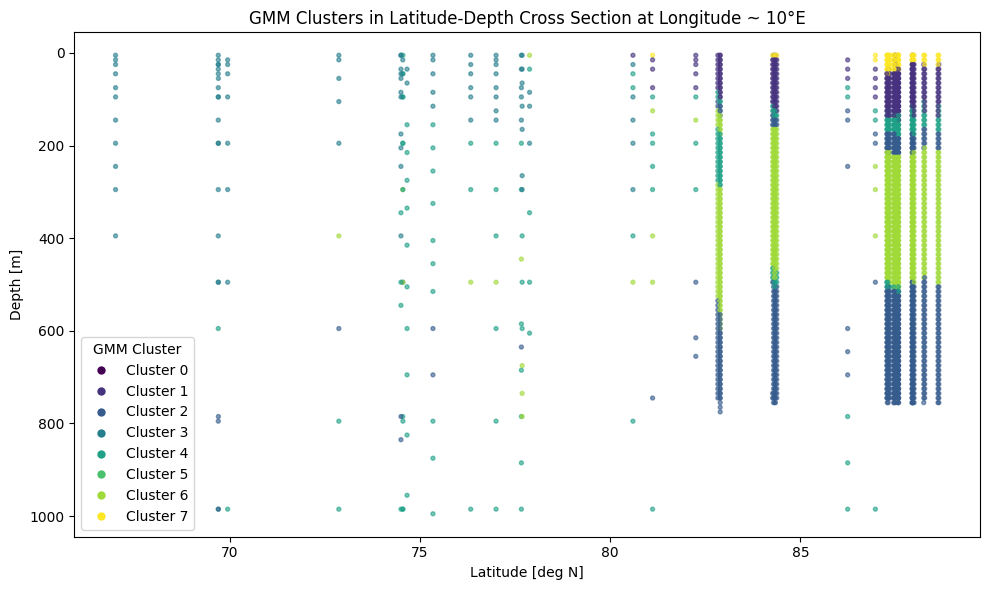

In [24]:
# Plot cross section for specific longitude slice
lon_val= 10
cross_sec_lon(lon_val, tol=0.5)

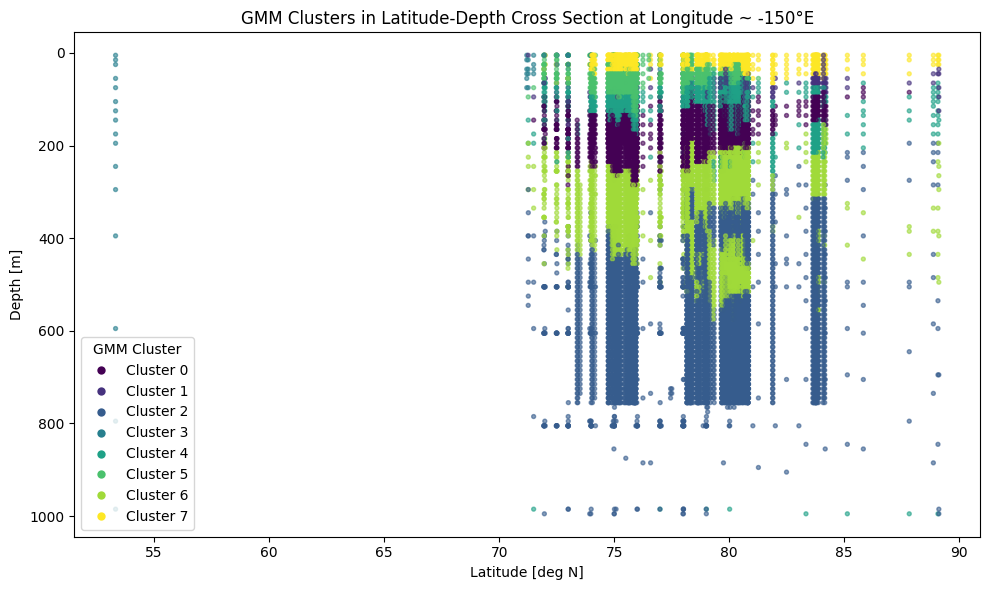

In [25]:
lon_val= -150
cross_sec_lon(lon_val, tol=0.5)

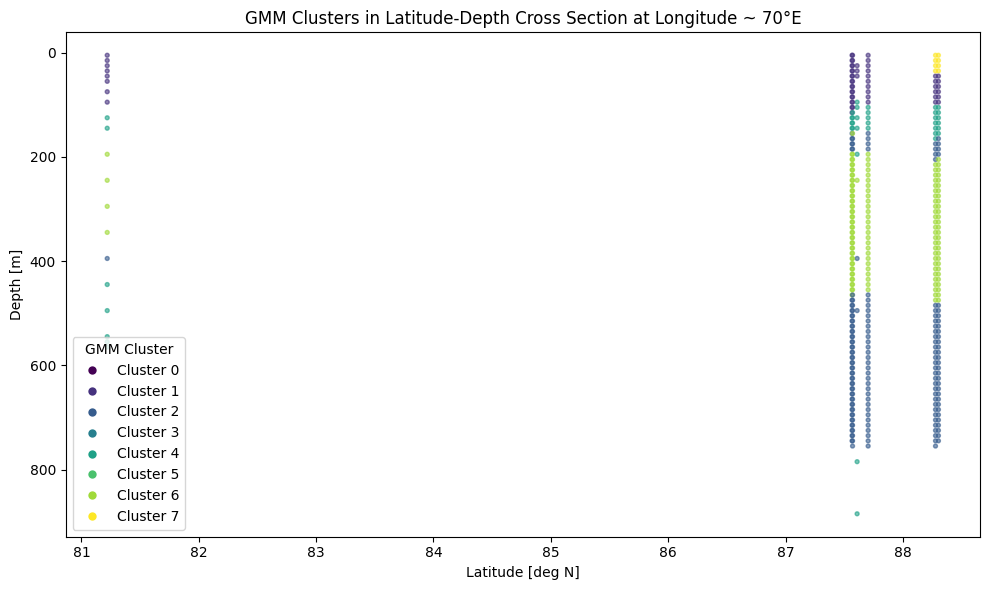

In [26]:
lon = 70
cross_sec_lon(lon, tol=0.5)

In [27]:
# Loss of information
X_recon_ae = autoencoder.predict(df_ST_scaled)
mse = np.mean((df_ST_scaled - X_recon_ae) ** 2)
print(f'Mean Squared Error of AE reconstruction: {mse}')

36580/36580 ━━━━━━━━━━━━━━━━━━━━ 23s 631us/step
Mean Squared Error of AE reconstruction: 0.004439824530362411


In [28]:
import gsw

In [29]:
df_ST['spice'] = gsw.spiciness0(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'])

In [30]:
from matplotlib.ticker import ScalarFormatter

def spice_histograms(df, spice_col='spice', label_col='gmm_label'):
    n_clusters = df[label_col].nunique()
    colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))

    fig, axes = plt.subplots(n_clusters, 1, figsize=(22, 10), sharex=True)

    if n_clusters == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        cluster_data = df[df[label_col] == i][spice_col]
        ax.hist(cluster_data, bins=30, alpha=0.5, color=colors[i], label=f'Cluster {i}')
        ax.legend()
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    fig.supxlabel('Spiciness')
    fig.supylabel('Frequency', x=0.01)
    fig.suptitle('Spiciness Histograms by GMM Cluster')

    x_min = max(-7, df[spice_col].min())
    x_max = df[spice_col].max()
    axes[0].set_xlim(x_min, x_max)

    plt.tight_layout()
    plt.show()

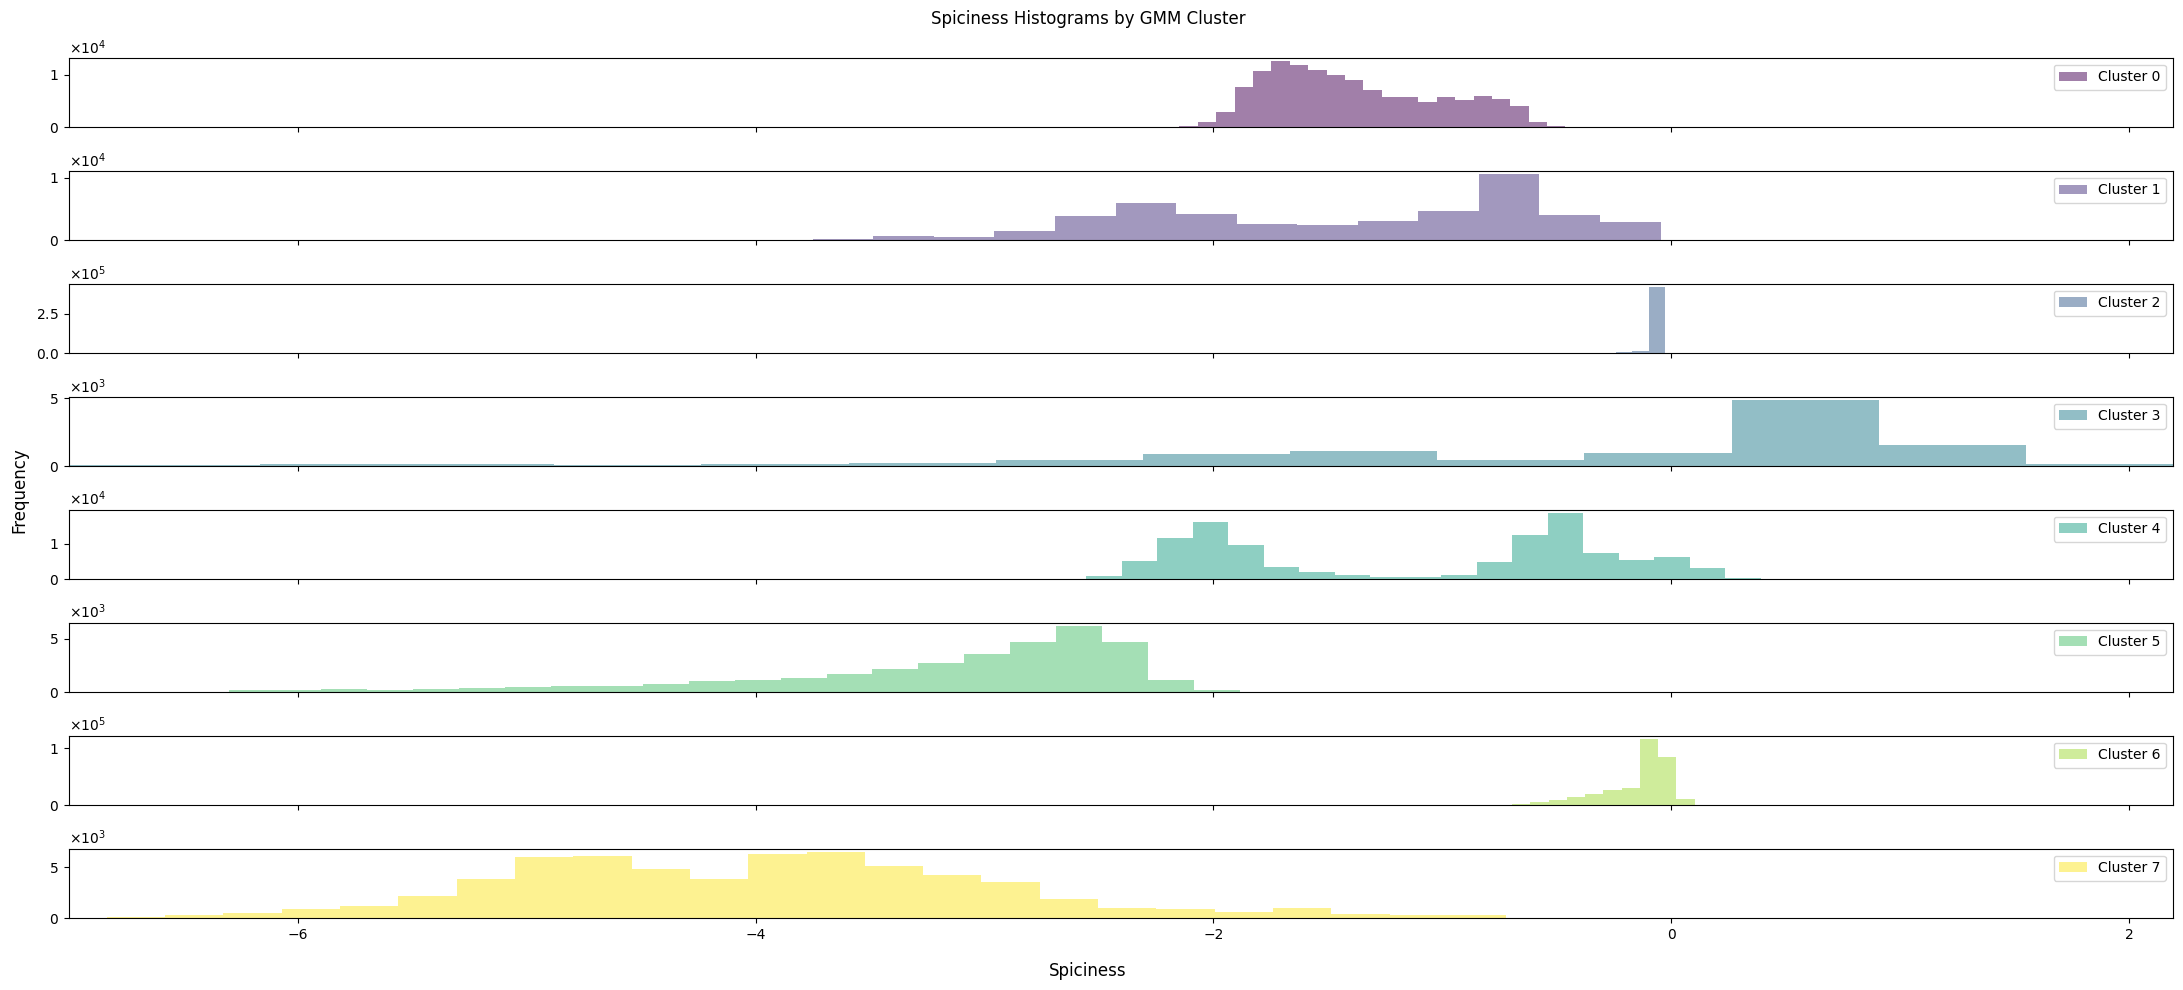

In [31]:
spice_histograms(df_ST)

In [40]:
probs = gmm.predict_proba(X_latent)
for k in range(probs.shape[1]):
    df_ST[f"prob_cluster_{k}"] = probs[:, k]

In [57]:
def cross_sec_lon_prob(lon_value, tol=0.5):
    df_lon_slice = df_ST[
        (df_ST['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_ST['Longitude_[deg_E]'] <= lon_value + tol)
    ]

    n = optimal_n_components
    cols = 2
    rows = (n + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), sharex=True, sharey=True)
    axes = axes.flatten()

    for i in range(n):
        ax = axes[i]
        sc = ax.scatter(
            df_lon_slice['Latitude_[deg_N]'],
            -df_lon_slice['Depth_[m]'],
            c=df_lon_slice[f'prob_cluster_{i}'],
            cmap='plasma',
            vmin=0, vmax=1,
            s=8,
            alpha=0.6
        )
        ax.invert_yaxis()
        ax.set_title(f'Cluster {i}')
        ax.set_xlabel('Latitude [deg N]')
        ax.set_ylabel('Depth [m]')
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{abs(x):.0f}'))

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Cluster Probabilities at Longitude ~ {lon_value}°E', fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.88, 1])

    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0, vmax=1))
    fig.colorbar(sm, cax=cbar_ax, label='Probability')

    plt.show()

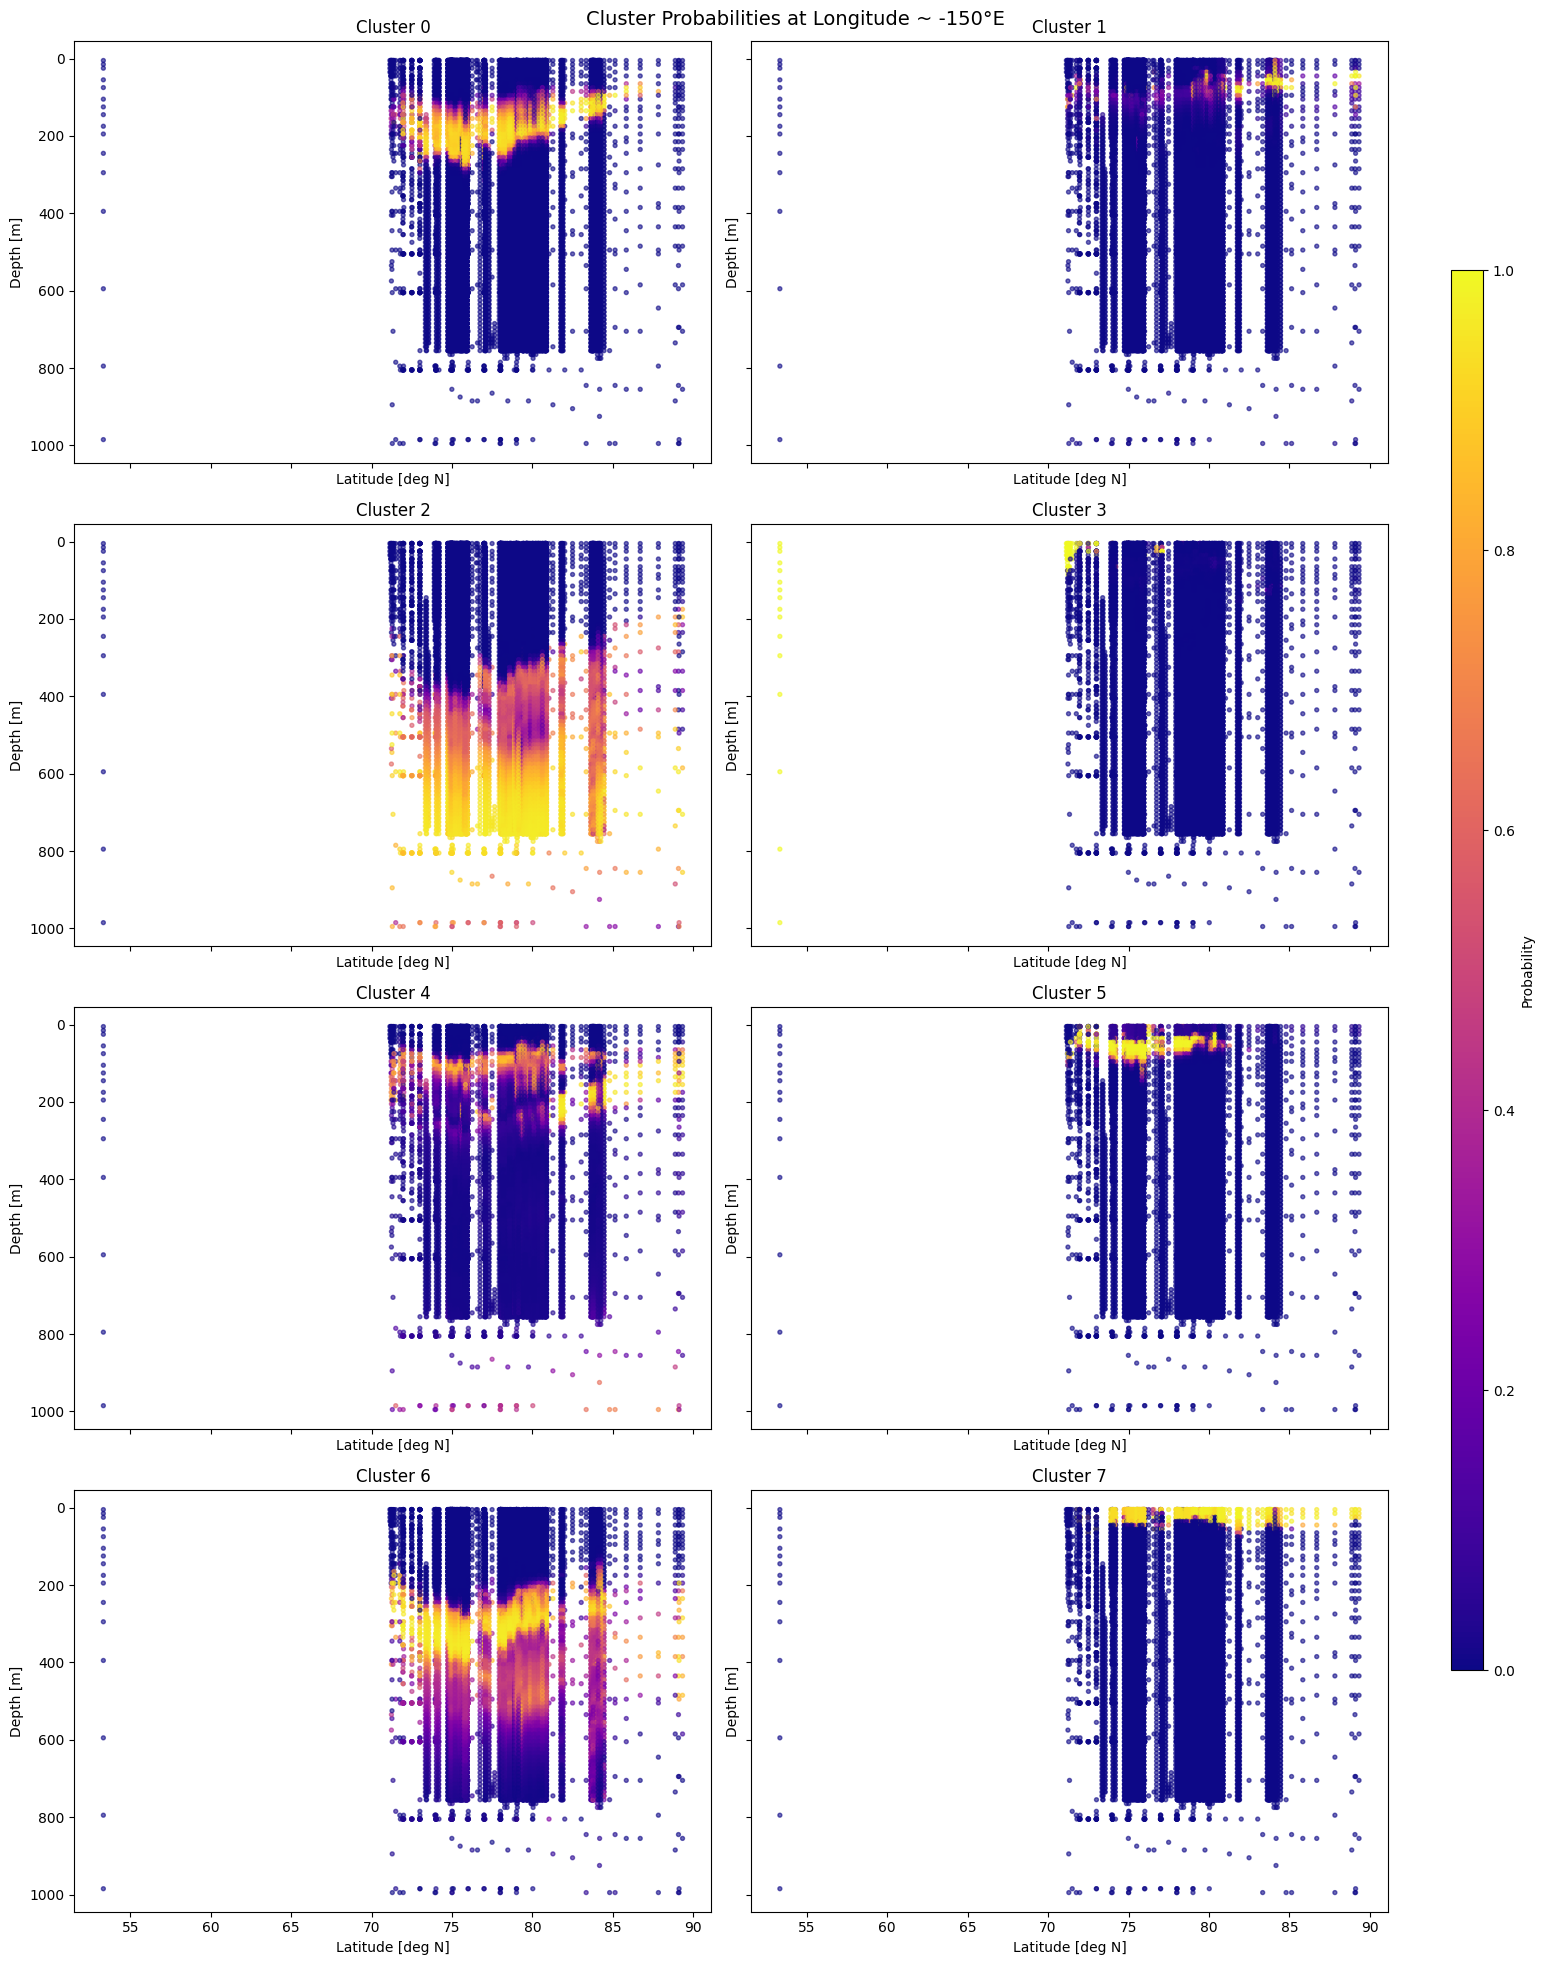

In [58]:
cross_sec_lon_prob(-150, tol=1)

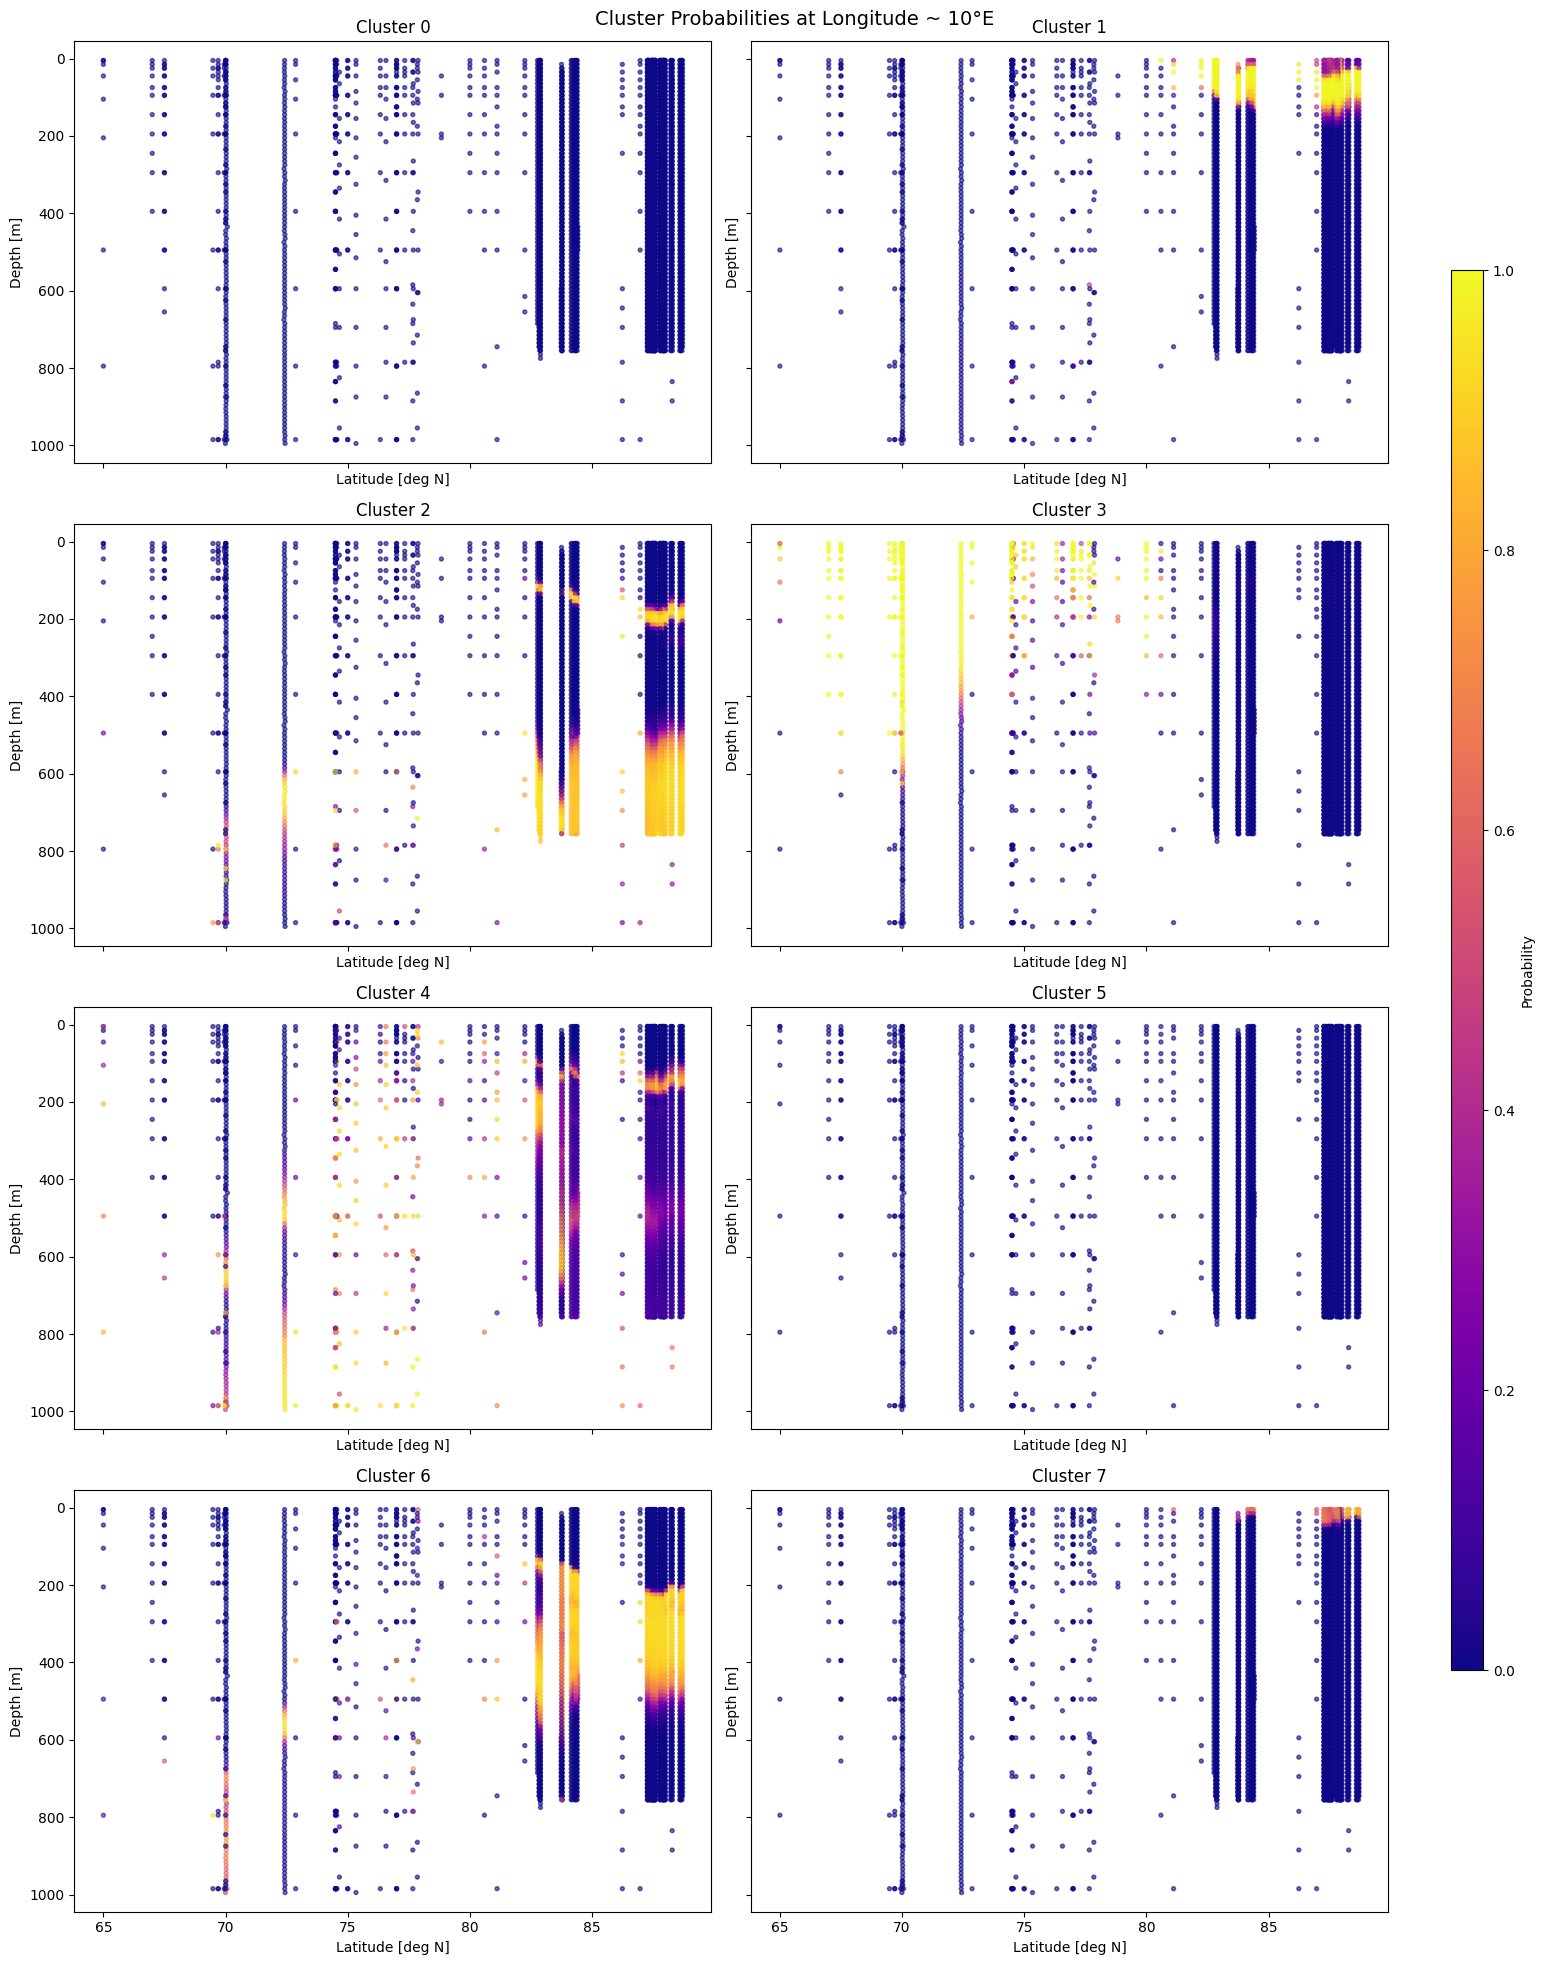

In [59]:
cross_sec_lon_prob(10, tol=1)

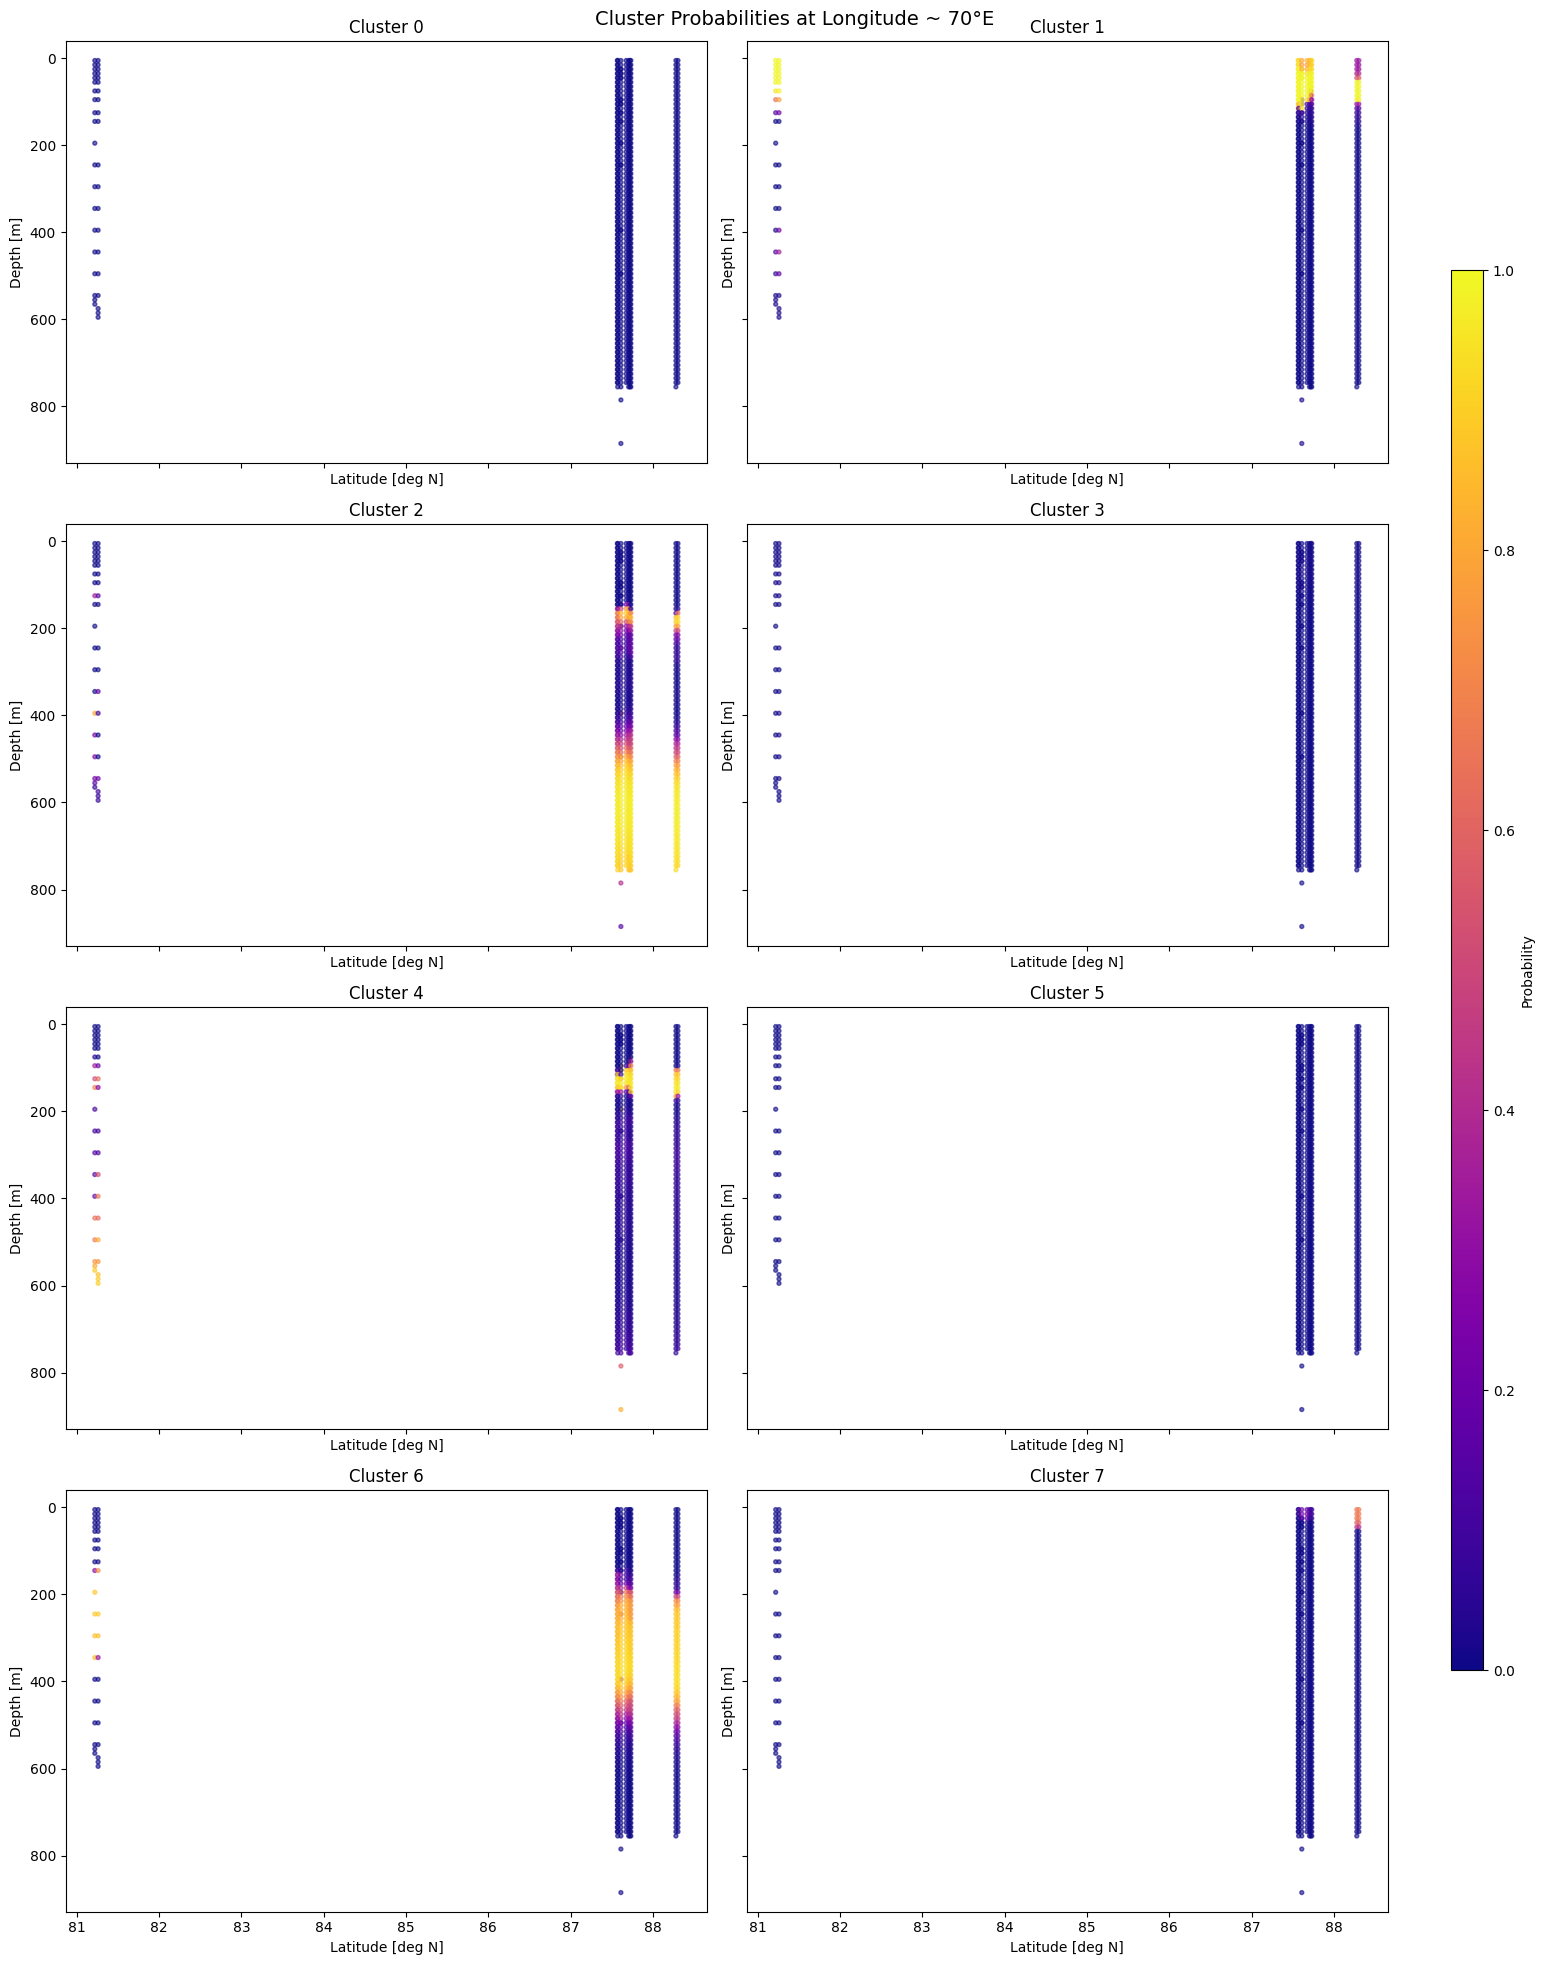

In [60]:
cross_sec_lon_prob(70, tol=1)